# 04 · Reinsurance

Quota share and unlimited per-claim excess of loss applied to the notebook 01 motor model. All annual figures are one policy-year in EUR. The gross baseline is checked against notebook 02.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
require_results('calibrated_model.json', 'loss_summary.json')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insurance_model import CalibratedModel, simulate_claims, aggregate, var, es
from reinsurance_model import quota_share, per_occurrence_xol


model = CalibratedModel.from_json(result_path('calibrated_model.json'))
RNG_SEED = 42
N_SIM = 500_000
EUR = lambda v: f"EUR {v:,.0f}"

## Baseline reconciliation

Same model, seed and sample size must reproduce notebook 02's simulated losses within numerical tolerance.

In [2]:
sim_index, severities = simulate_claims(N_SIM, model, np.random.default_rng(RNG_SEED))
gross = aggregate(sim_index, severities, N_SIM)
v_gross, e_gross, mean_gross = var(gross, 0.995), es(gross, 0.995), gross.mean()

nb02_summary = json.load(open(result_path('loss_summary.json')))

print(f"This notebook's gross baseline:  mean={mean_gross:.2f}  VaR99.5={v_gross:.2f}  ES99.5={e_gross:.2f}")
print(f"Notebook 02's saved baseline:    mean={nb02_summary['mean_loss']:.2f}  VaR99.5={nb02_summary['var_995']:.2f}  ES99.5={nb02_summary['es_995']:.2f}")

assert np.isclose(v_gross, nb02_summary['var_995']), "VaR mismatch vs Notebook 02 -- shared model/engine has drifted!"
assert np.isclose(mean_gross, nb02_summary['mean_loss'], rtol=1e-6), "Mean mismatch vs Notebook 02!"
print("\nConsistency check passed: identical seed + shared model/engine reproduces Notebook 02's baseline exactly.")

claims_per_year = np.bincount(sim_index, minlength=N_SIM)
dist = np.bincount(claims_per_year)
print(f"\nClaims-per-year distribution (n={N_SIM:,}): " +
      ", ".join(f"{k} claims: {v/N_SIM:.2%}" for k, v in enumerate(dist[:5])))


This notebook's gross baseline:  mean=350.43  VaR99.5=6247.40  ES99.5=45791.51
Notebook 02's saved baseline:    mean=350.43  VaR99.5=6247.40  ES99.5=45791.51

Consistency check passed: identical seed + shared model/engine reproduces Notebook 02's baseline exactly.

Claims-per-year distribution (n=500,000): 0 claims: 90.87%, 1 claims: 8.15%, 2 claims: 0.87%, 3 claims: 0.10%, 4 claims: 0.01%


## Quota share

A fraction q of every claim is ceded. Gross = retained + ceded is checked at the annual level.

In [3]:
qs_shares = [0.10, 0.25, 0.50, 0.75]
qs_rows = []
for q in qs_shares:
    net_sev, ceded_sev = quota_share(severities, q)
    net_claim_level = aggregate(sim_index, net_sev, N_SIM)
    net_from_gross = gross * (1 - q)   # aggregate-level shortcut, for the equivalence check
    assert np.allclose(net_claim_level, net_from_gross), "claim-level and aggregate-level QS must agree exactly"

    ceded_annual = aggregate(sim_index, ceded_sev, N_SIM)
    np.testing.assert_allclose(gross, net_claim_level + ceded_annual, rtol=1e-12, atol=1e-8)
    v_net, e_net = var(net_claim_level, 0.995), es(net_claim_level, 0.995)
    e_ceded = ceded_annual.mean()
    qs_rows.append(dict(q=q, VaR_net=v_net, ES_net=e_net, VaR_relief=v_gross - v_net, ES_relief=e_gross - e_net,
                         expected_ceded_loss=e_ceded,
                         eff_VaR=(v_gross - v_net)/e_ceded, eff_ES=(e_gross - e_net)/e_ceded))

qs_table = pd.DataFrame(qs_rows)
qs_table.round(2)

,q,VaR_net,ES_net,VaR_relief,ES_relief,expected_ceded_loss,eff_VaR,eff_ES
0,0.100,"5,622.660","41,212.360",624.740,"4,579.150",35.040,17.830,130.670
1,0.250,"4,685.550","34,343.630","1,561.850","11,447.880",87.610,17.830,130.670
2,0.500,"3,123.700","22,895.750","3,123.700","22,895.750",175.210,17.830,130.670
3,0.750,"1,561.850","11,447.880","4,685.550","34,343.630",262.820,17.830,130.670


Proportional cession commutes with aggregation, so for a fixed sample the ratio of VaR relief to ceded expected loss doesn't depend on q.

## Excess of loss

Retention R applies to each claim before aggregation: retained = min(claim, R). Cover above R is unlimited, with no reinstatements or aggregate limits.

In [4]:
retentions = [300, 500, 800, 1200, 2000, 3000, 5000, 8000, 12000, round(model.threshold), 25000, 40000, 60000, 100000]
xol_rows = []
for R in retentions:
    net_per_claim, ceded_per_claim = per_occurrence_xol(severities, R)
    net_annual = aggregate(sim_index, net_per_claim, N_SIM)
    ceded_annual = aggregate(sim_index, ceded_per_claim, N_SIM)

    np.testing.assert_allclose(gross, net_annual + ceded_annual, rtol=1e-12, atol=1e-8)
    v_net, e_net = var(net_annual, 0.995), es(net_annual, 0.995)
    e_ceded = ceded_annual.mean()
    eff_v = (v_gross - v_net)/e_ceded if e_ceded > 0 else np.nan
    eff_e = (e_gross - e_net)/e_ceded if e_ceded > 0 else np.nan
    xol_rows.append(dict(R=R, VaR_net=v_net, ES_net=e_net, VaR_relief=v_gross - v_net, ES_relief=e_gross - e_net,
                          expected_ceded_loss=e_ceded, eff_VaR=eff_v, eff_ES=eff_e))

xol_table = pd.DataFrame(xol_rows)
xol_table.round(2)

,R,VaR_net,ES_net,VaR_relief,ES_relief,expected_ceded_loss,eff_VaR,eff_ES
0,300,600.000,643.160,"5,647.400","45,148.340",321.430,17.570,140.460
1,500,"1,000.000","1,077.970","5,247.400","44,713.530",305.410,17.180,146.410
2,800,"1,349.700","1,654.610","4,897.690","44,136.900",286.040,17.120,154.300
3,1200,"1,681.660","2,239.890","4,565.730","43,551.620",266.590,17.130,163.370
4,2000,"2,232.820","3,103.690","4,014.570","42,687.820",240.890,16.670,177.210
5,3000,"3,000.000","3,295.360","3,247.400","42,496.140",221.890,14.640,191.520
6,5000,"5,000.000","5,388.060","1,247.400","40,403.450",202.390,6.160,199.630
7,8000,"6,247.400","7,950.920",0.000,"37,840.580",189.200,0.000,200.000
8,12000,"6,247.400","9,655.770",0.000,"36,135.740",180.680,0.000,200.000
9,16794,"6,247.400","10,855.620",0.000,"34,935.880",174.680,0.000,200.000


### Simulation variability

The treaty calculations are repeated over 15 seeds. Error bars are replicate standard deviations, not confidence intervals for the population.

In [5]:
N_SEEDS = 15
xol_eff_var_runs = {R: [] for R in retentions}
xol_eff_es_runs = {R: [] for R in retentions}
qs_eff_var_runs, qs_eff_es_runs = [], []

for s in range(N_SEEDS):
    sim_idx_s, sev_s = simulate_claims(N_SIM, model, np.random.default_rng(9000 + s))
    gross_s = aggregate(sim_idx_s, sev_s, N_SIM)
    v_gross_s, e_gross_s, mean_gross_s = var(gross_s, 0.995), es(gross_s, 0.995), gross_s.mean()

    qs_eff_var_runs.append(v_gross_s / mean_gross_s)
    qs_eff_es_runs.append(e_gross_s / mean_gross_s)

    for R in retentions:
        ceded_s = np.clip(sev_s - R, 0, None)
        net_s = sev_s - ceded_s
        net_annual_s = aggregate(sim_idx_s, net_s, N_SIM)
        ceded_annual_s = aggregate(sim_idx_s, ceded_s, N_SIM)
        v_net_s, e_net_s = var(net_annual_s, 0.995), es(net_annual_s, 0.995)
        e_ceded_s = ceded_annual_s.mean()
        if e_ceded_s > 0:
            xol_eff_var_runs[R].append((v_gross_s - v_net_s) / e_ceded_s)
            xol_eff_es_runs[R].append((e_gross_s - e_net_s) / e_ceded_s)

xol_uncertainty = pd.DataFrame({
    'R': retentions,
    'eff_VaR_mean': [np.mean(xol_eff_var_runs[R]) for R in retentions],
    'eff_VaR_std': [np.std(xol_eff_var_runs[R]) for R in retentions],
    'eff_ES_mean': [np.mean(xol_eff_es_runs[R]) for R in retentions],
    'eff_ES_std': [np.std(xol_eff_es_runs[R]) for R in retentions],
})
qs_eff_var_mean, qs_eff_var_std = np.mean(qs_eff_var_runs), np.std(qs_eff_var_runs)
qs_eff_es_mean, qs_eff_es_std = np.mean(qs_eff_es_runs), np.std(qs_eff_es_runs)

print(f"Quota share, across {N_SEEDS} seeds:  eff_VaR = {qs_eff_var_mean:.1f} +/- {qs_eff_var_std:.1f}   "
      f"eff_ES = {qs_eff_es_mean:.1f} +/- {qs_eff_es_std:.1f}")
xol_uncertainty.round(2)

Quota share, across 15 seeds:  eff_VaR = 23.0 +/- 3.7   eff_ES = 110.3 +/- 14.5


,R,eff_VaR_mean,eff_VaR_std,eff_ES_mean,eff_ES_std
0,300,23.340,4.080,120.550,13.960
1,500,23.280,4.280,127.000,13.500
2,800,23.940,4.700,135.950,12.670
3,1200,24.780,5.250,146.800,11.330
4,2000,25.510,6.070,164.820,8.400
5,3000,23.550,6.180,185.920,3.740
6,5000,10.650,3.170,199.300,0.250
7,8000,0.000,0.000,200.000,0.000
8,12000,0.000,0.000,200.000,0.000
9,16794,0.000,0.000,200.000,0.000


Efficiency ratios depend on the tail relief and on the estimated ceded mean, and under this heavy tail both vary from seed to seed.

When the retention is above the relevant annual quantile, VaR relief can disappear while ES still shows the extreme losses being transferred. The sample results below show where that happens.

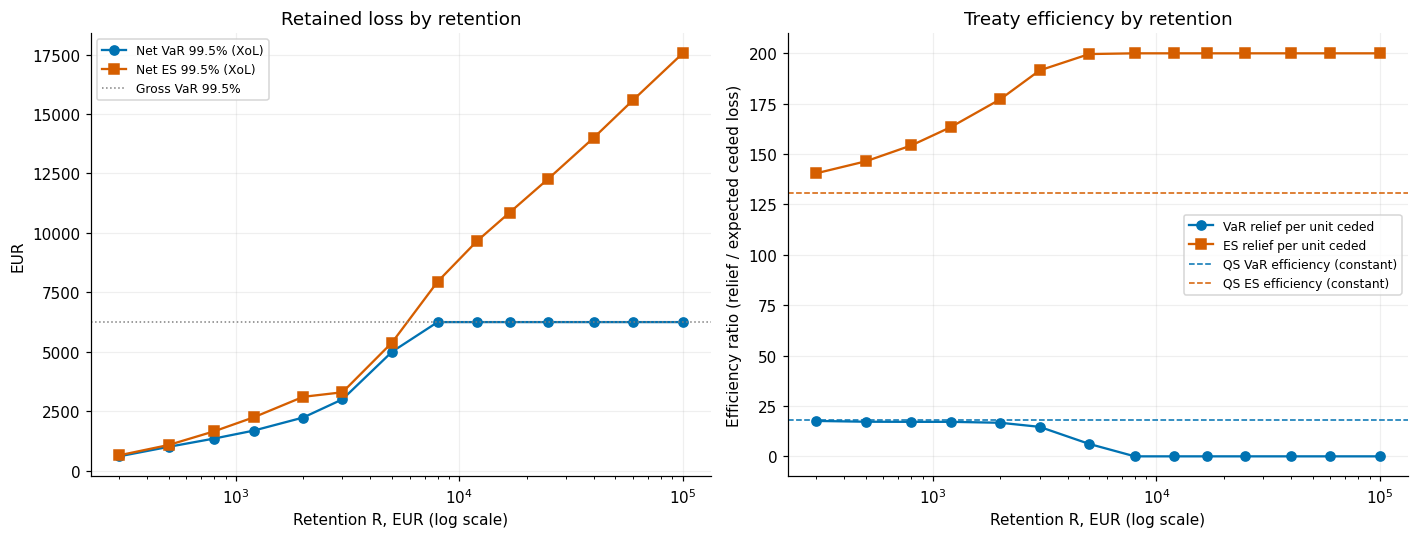

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(xol_table['R'], xol_table['VaR_net'], 'o-', label='Net VaR 99.5% (XoL)', color='C0')
axes[0].plot(xol_table['R'], xol_table['ES_net'], 's-', label='Net ES 99.5% (XoL)', color='C3')
axes[0].axhline(v_gross, color='gray', ls=':', lw=1, label='Gross VaR 99.5%')
axes[0].set_xscale('log')
axes[0].set_xlabel('Retention R, EUR (log scale)'); axes[0].set_ylabel('EUR')
axes[0].set_title('Retained loss by retention')
axes[0].legend(fontsize=8)

axes[1].plot(xol_table['R'], xol_table['eff_VaR'], 'o-', label='VaR relief per unit ceded', color='C0')
axes[1].plot(xol_table['R'], xol_table['eff_ES'], 's-', label='ES relief per unit ceded', color='C3')
axes[1].axhline(qs_table['eff_VaR'].iloc[0], color='C0', ls='--', lw=1, label='QS VaR efficiency (constant)')
axes[1].axhline(qs_table['eff_ES'].iloc[0], color='C3', ls='--', lw=1, label='QS ES efficiency (constant)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Retention R, EUR (log scale)'); axes[1].set_ylabel('Efficiency ratio (relief / expected ceded loss)')
axes[1].set_title('Treaty efficiency by retention')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Risk-transfer efficiency

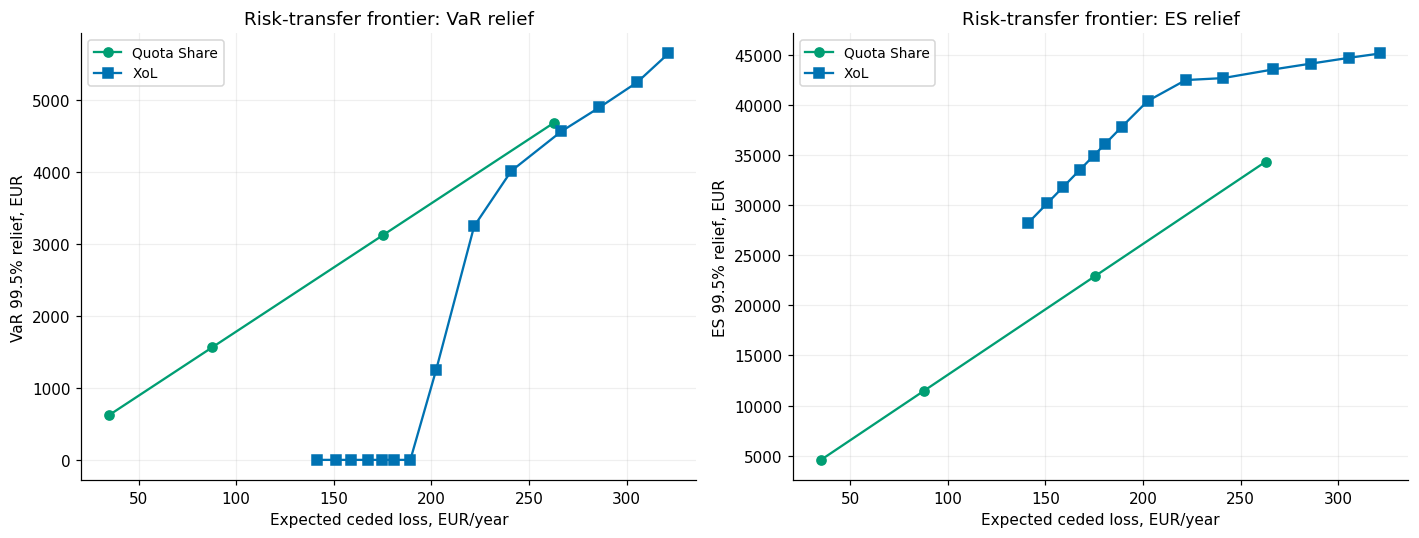

QS efficiency (constant):     VaR=17.83   ES=130.67
XoL efficiency range tested:  VaR 0.00-17.57   ES 140.46-200.00


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(qs_table['expected_ceded_loss'], qs_table['VaR_relief'], 'o-', label='Quota Share', color='C2')
axes[0].plot(xol_table['expected_ceded_loss'], xol_table['VaR_relief'], 's-', label='XoL', color='C0')
axes[0].set_xlabel('Expected ceded loss, EUR/year'); axes[0].set_ylabel('VaR 99.5% relief, EUR')
axes[0].set_title('Risk-transfer frontier: VaR relief')
axes[0].legend()

axes[1].plot(qs_table['expected_ceded_loss'], qs_table['ES_relief'], 'o-', label='Quota Share', color='C2')
axes[1].plot(xol_table['expected_ceded_loss'], xol_table['ES_relief'], 's-', label='XoL', color='C0')
axes[1].set_xlabel('Expected ceded loss, EUR/year'); axes[1].set_ylabel('ES 99.5% relief, EUR')
axes[1].set_title('Risk-transfer frontier: ES relief')
axes[1].legend()

plt.tight_layout(); plt.show()

print(f"QS efficiency (constant):     VaR={qs_table['eff_VaR'].iloc[0]:.2f}   ES={qs_table['eff_ES'].iloc[0]:.2f}")
print(f"XoL efficiency range tested:  VaR {xol_table['eff_VaR'].min():.2f}-{xol_table['eff_VaR'].max():.2f}   "
      f"ES {xol_table['eff_ES'].min():.2f}-{xol_table['eff_ES'].max():.2f}")

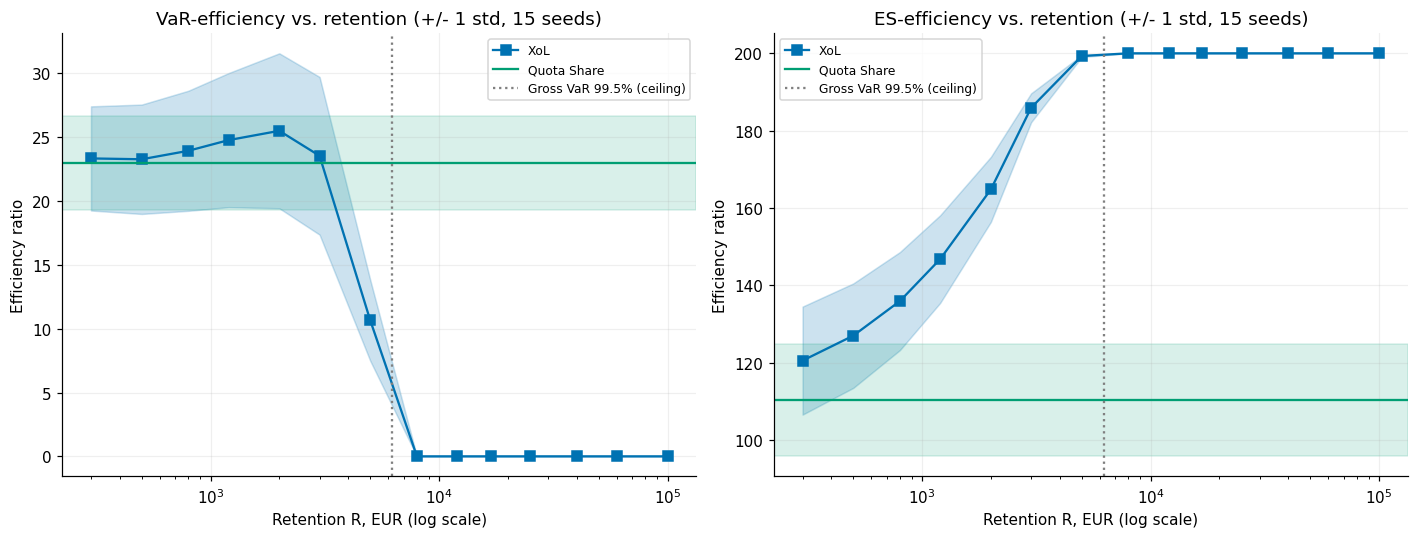

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col_mean, col_std, qs_mean, qs_std, title in [
    (axes[0], 'eff_VaR_mean', 'eff_VaR_std', qs_eff_var_mean, qs_eff_var_std, 'VaR-efficiency vs. retention (+/- 1 std, 15 seeds)'),
    (axes[1], 'eff_ES_mean', 'eff_ES_std', qs_eff_es_mean, qs_eff_es_std, 'ES-efficiency vs. retention (+/- 1 std, 15 seeds)'),
]:
    m, s = xol_uncertainty[col_mean], xol_uncertainty[col_std]
    ax.plot(xol_uncertainty['R'], m, 's-', color='C0', label='XoL')
    ax.fill_between(xol_uncertainty['R'], m - s, m + s, color='C0', alpha=0.2)
    ax.axhline(qs_mean, color='C2', ls='-', label='Quota Share')
    ax.axhspan(qs_mean - qs_std, qs_mean + qs_std, color='C2', alpha=0.15)
    ax.axvline(v_gross, color='gray', ls=':', label='Gross VaR 99.5% (ceiling)')
    ax.set_xscale('log')
    ax.set_xlabel('Retention R, EUR (log scale)'); ax.set_ylabel('Efficiency ratio')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

The frontier compares modeled loss transfer at the retentions tested. It says nothing about actual treaty prices or counterparty quality.

## Treaty pricing

Expected ceded loss is a loss-cost estimate. A real reinsurance premium also includes expenses, capital cost, profit and contract terms.

## Gross and retained stress losses

25% quota share and unlimited per-claim XoL above EUR 5,000. Within each scenario both treaties use the same gross draws.

In [9]:
from dataclasses import replace
stress_rows = []
for label, fm, sm, xi in [('Baseline', 1, 1, model.xi_gpd), ('Frequency +50%', 1.5, 1, model.xi_gpd),
                           ('Severity +50%', 1, 1.5, model.xi_gpd), ('Combined', 1.5, 1.5, model.xi_gpd),
                           ('Tail shape 0.95', 1, 1, 0.95)]:
    idx, claims = simulate_claims(N_SIM, replace(model, xi_gpd=xi), np.random.default_rng(RNG_SEED), fm, sm)
    gross_stress = aggregate(idx, claims, N_SIM)
    for treaty, retained in [('QS 25%', quota_share(claims, 0.25)[0]), ('XoL 5000', per_occurrence_xol(claims, 5000)[0])]:
        net = aggregate(idx, retained, N_SIM)
        ceded = aggregate(idx, claims - retained, N_SIM)
        np.testing.assert_allclose(gross_stress, net + ceded, rtol=1e-12, atol=1e-8)
        stress_rows.append(dict(scenario=label, treaty=treaty, gross_var=var(gross_stress,.995),
                               net_var=var(net,.995), gross_es=es(gross_stress,.995), net_es=es(net,.995)))
reinsurance_stress = pd.DataFrame(stress_rows)
display(reinsurance_stress.round(1))
json.dump({'currency':'EUR', 'horizon':'one policy-year', 'stress':stress_rows},
          open(result_path('reinsurance_results.json'),'w'), indent=2)

,scenario,treaty,gross_var,net_var,gross_es,net_es
0,Baseline,QS 25%,"6,247.400","4,685.500","45,791.500","34,343.600"
1,Baseline,XoL 5000,"6,247.400","5,000.000","45,791.500","5,388.100"
2,Frequency +50%,QS 25%,"8,126.300","6,094.700","33,031.900","24,773.900"
3,Frequency +50%,XoL 5000,"8,126.300","5,000.000","33,031.900","5,557.300"
4,Severity +50%,QS 25%,"9,371.100","7,028.300","68,687.300","51,515.400"
5,Severity +50%,XoL 5000,"9,371.100","5,000.000","68,687.300","5,475.200"
6,Combined,QS 25%,"12,189.400","9,142.000","49,547.800","37,160.900"
7,Combined,XoL 5000,"12,189.400","5,789.300","49,547.800","7,630.400"
8,Tail shape 0.95,QS 25%,"6,247.400","4,685.500","70,264.400","52,698.300"
9,Tail shape 0.95,XoL 5000,"6,247.400","5,000.000","70,264.400","5,388.100"


## Notes

- Gross, retained and ceded losses reconcile in the baseline and in every stress case.
- Baseline: a 25% quota share cuts VaR 99.5% from EUR 6,247 to 4,686. XoL at 5,000 caps it at 5,000 and brings ES from 45,792 down to about 5,400.
- Quota share scales every loss; XoL caps each retained claim.
- Ceded expected loss is not a quoted treaty premium.

In [10]:
record_results('reinsurance_results.json')